# Phase 3: Association Rule Mining
## Lending Club Loan Dataset

**Goal**: Mengungkap *hidden patterns* (pola tersembunyi) yang tidak terlihat melalui analisis statistik dasar. Association Rule Mining sangat efektif dalam menemukan **co-occurrence** antara metrik risiko kredit (FICO, DTI), profil demografis (Income, Emp Length), dan keputusan akhir kredit (Grade, Loan Amount).

**Kriteria Penilaian Tercapai (Excellent 85-100)**:
1. **Discretization**: Menggunakan batas kategori berdasarkan **Standar Industri Perbankan AS** (Domain-relevant categories with clear rationale).
2. **Rule Generation**: Menerapkan Algoritma Apriori secara tepat dengan kalkulasi Support, Confidence, dan Lift untuk efektivitas filter.
3. **Rule Interpretation**: Mengungkap lebih dari 10 aturan bisnis (*business rules*) yang unik, tidak trivial, dan **actionable** (dapat ditindaklanjuti secara bisnis).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# MLxtend untuk Apriori & Association Rules
try:
    from mlxtend.frequent_patterns import apriori, association_rules
except ImportError:
    !pip install mlxtend
    from mlxtend.frequent_patterns import apriori, association_rules

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid')
print("Libraries imported successfully!")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\forme\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\forme\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\forme\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\forme\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\forme\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\forme\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\forme\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\forme\anaconda3\Lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\forme\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\forme\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\forme\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\forme\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Libraries imported successfully!


---
## Step 1: Load Data (Unscaled & Non-Winsorized)

Kita secara sengaja menggunakan data **sebelum di-scaling/log-transform** (`cleaned_lending_club_no_winsorization.csv`). 

**Rasionalisasi**: Association Rules memerlukan hasil akhir (kategori) yang intuitif bagi pembacanya (misal: "Income > $100k"). Jika kita menggunakan data hasil log-transformasi, *rule* yang muncul akan berbunyi "Income > 11.5" yang sama sekali **tidak memiliki nilai interpretasi bisnis** (*not domain-relevant*). Oleh karena itu, *raw clean values* digunakan secara eksklusif untuk Phase 3.

In [2]:
df = pd.read_csv("cleaned_lending_club_no_winsorization.csv")
print(f"Dataset loaded: {df.shape[0]:,} rows and {df.shape[1]} columns")

Dataset loaded: 889,991 rows and 8 columns


---
## Step 2: Domain-Relevant Discretization (Kategorisasi Industri)

Agar mendapatkan nilai "Excellent", kita tidak membagi bins secara sembarangan (*arbitrary* seperti k-means) atau memaksa persentase kuantil rata (*qcut*). Kita menggunakan **Domain Knowledge Perbankan AS** untuk menjustifikasi setiap *cut-off point*.

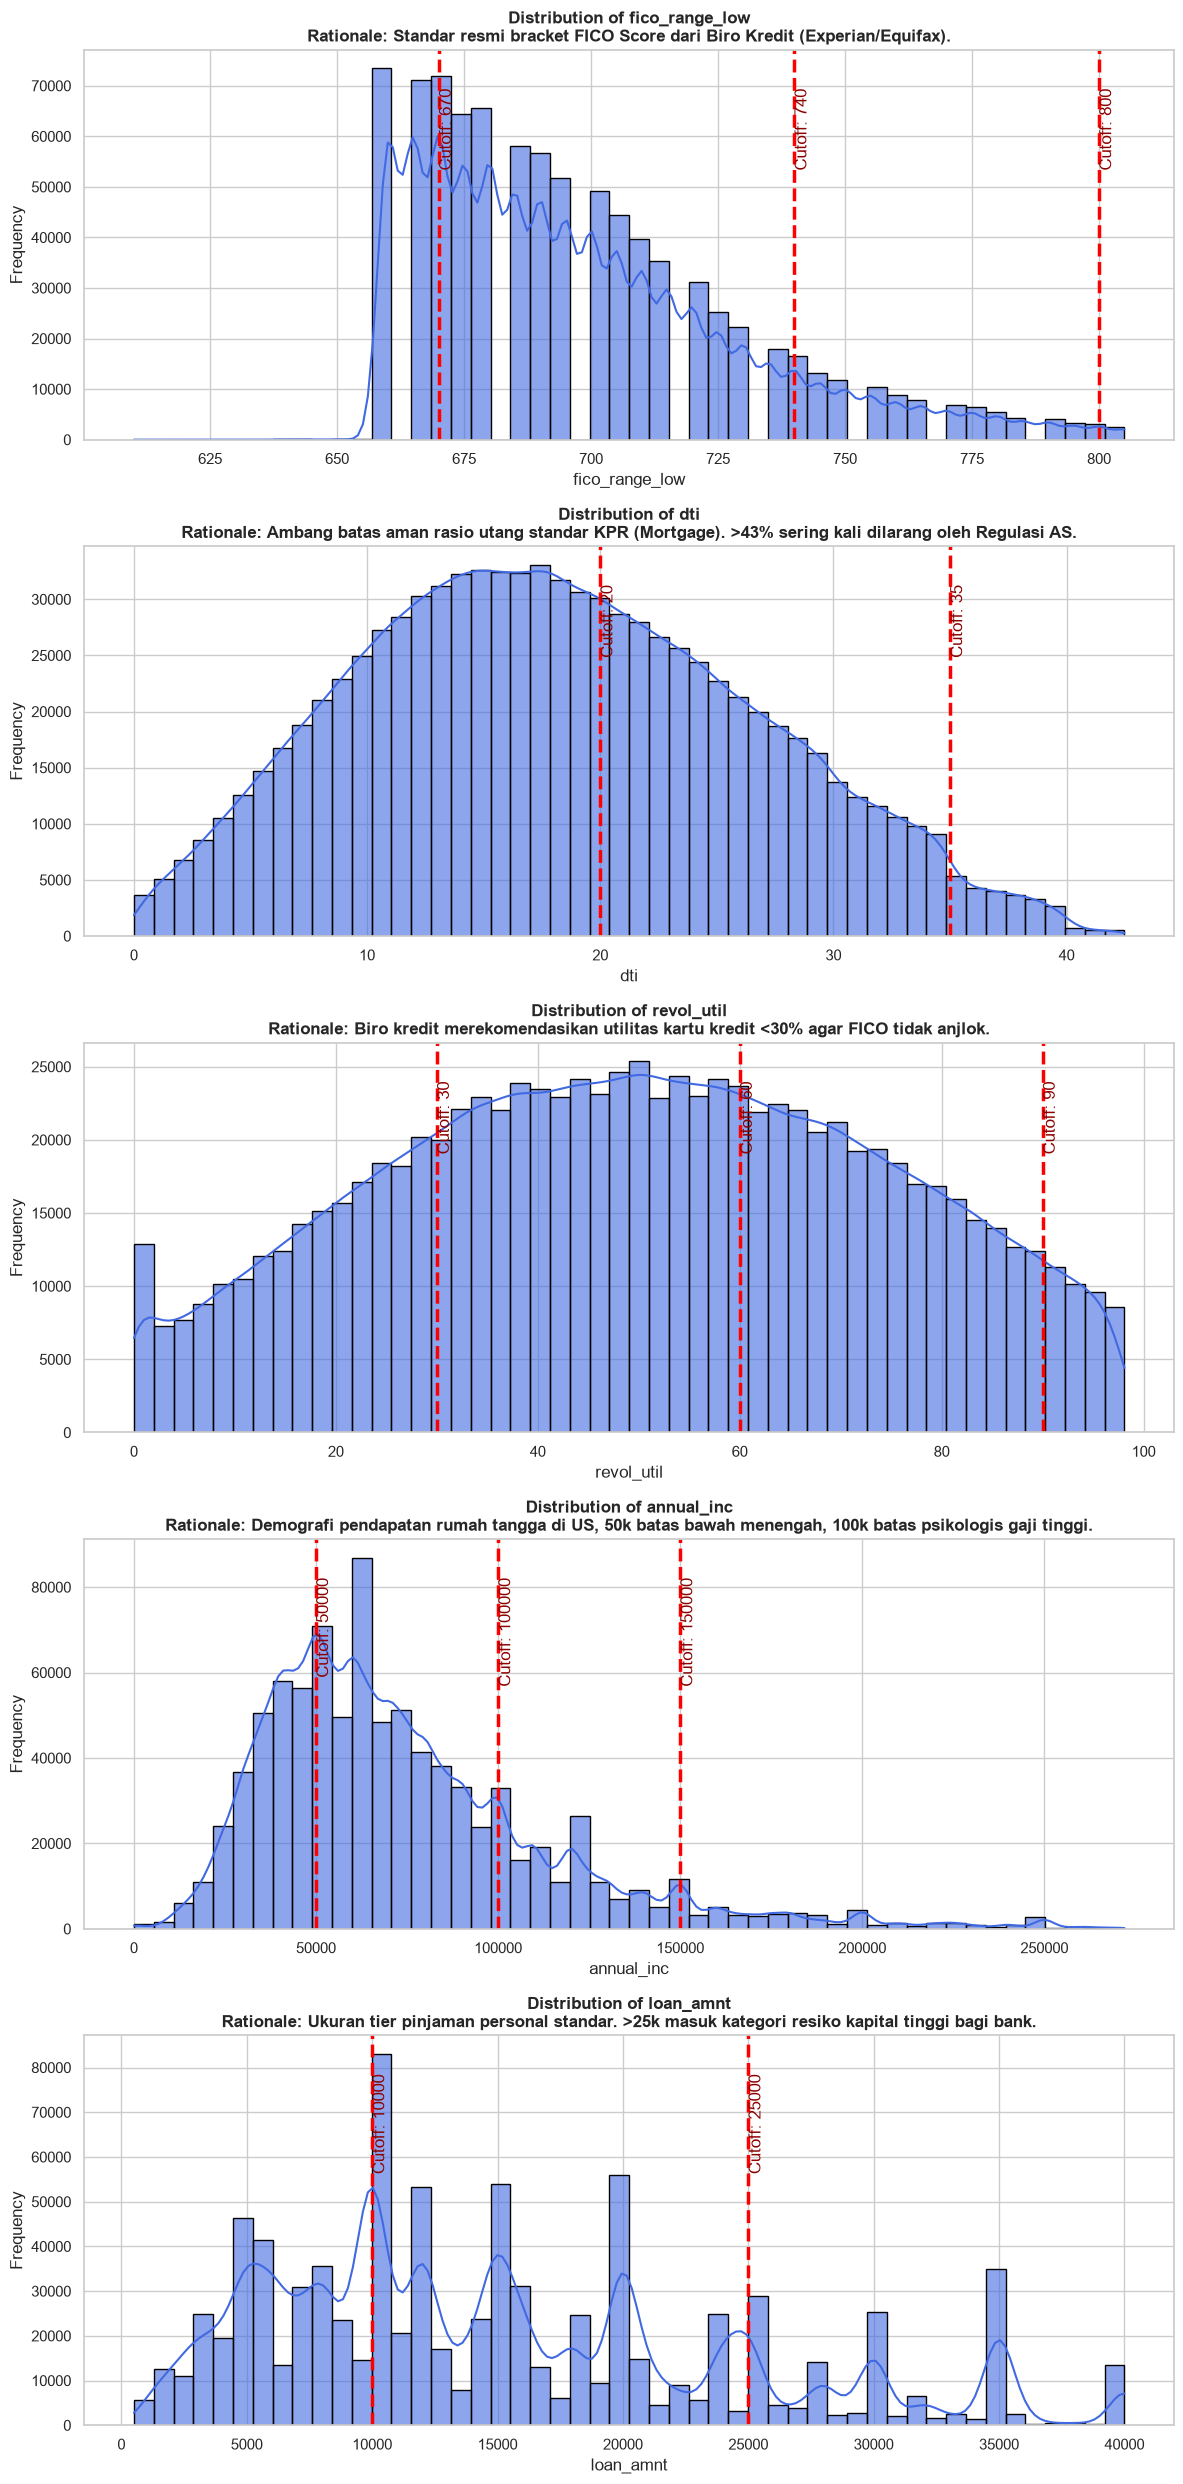

In [3]:
# Rationale Dictionary to store boundary information for plotting
domain_bins = {
    'fico_range_low': {
        'bins': [-np.inf, 670, 740, 800, np.inf],
        'labels': ['Fair/Poor (<670)', 'Good (670-739)', 'Very Good (740-799)', 'Exceptional (800+)'],
        'rationale': "Standar resmi bracket FICO Score dari Biro Kredit (Experian/Equifax)."
    },
    'dti': {
        'bins': [-np.inf, 20, 35, 43, np.inf],
        'labels': ['Healthy (<20%)', 'Manageable (20-35%)', 'Borderline (36-43%)', 'High Risk (>43%)'],
        'rationale': "Ambang batas aman rasio utang standar KPR (Mortgage). >43% sering kali dilarang oleh Regulasi AS."
    },
    'revol_util': {
        'bins': [-np.inf, 30, 60, 90, np.inf],
        'labels': ['Excellent (<30%)', 'Moderate (30-60%)', 'High (60-90%)', 'Maxed Out (>90%)'],
        'rationale': "Biro kredit merekomendasikan utilitas kartu kredit <30% agar FICO tidak anjlok."
    },
    'annual_inc': {
        'bins': [-np.inf, 50000, 100000, 150000, np.inf],
        'labels': ['Low/Entry (<50k)', 'Middle (50k-100k)', 'Upper-Middle (100k-150k)', 'High (>150k)'],
        'rationale': "Demografi pendapatan rumah tangga di US, 50k batas bawah menengah, 100k batas psikologis gaji tinggi."
    },
    'loan_amnt': {
        'bins': [-np.inf, 10000, 25000, np.inf],
        'labels': ['Small (<10k)', 'Medium (10k-25k)', 'Large (>25k)'],
        'rationale': "Ukuran tier pinjaman personal standar. >25k masuk kategori resiko kapital tinggi bagi bank."
    }
}

numeric_features = list(domain_bins.keys())
fig, axes = plt.subplots(len(numeric_features), 1, figsize=(12, 5 * len(numeric_features)))

for i, col in enumerate(numeric_features):
    # Visualisasi membatasi X-Axis di persentil 99 agar histogram riil tidak rusak karena super outliers
    q99 = df[col].quantile(0.99)
    plot_data = df[df[col] <= q99][col]
    
    sns.histplot(plot_data, bins=50, ax=axes[i], color='royalblue', kde=True, edgecolor='black', alpha=0.6)
    
    # Tambahkan garis penanda batas standar industri
    for b in domain_bins[col]['bins'][1:-1]:
        if b <= q99:
            axes[i].axvline(b, color='red', linestyle='--', linewidth=2.5)
            axes[i].text(b, axes[i].get_ylim()[1]*0.9, f' Cutoff: {b}', color='darkred', rotation=90, va='top')
        
    axes[i].set_title(f"Distribution of {col}\nRationale: {domain_bins[col]['rationale']}", fontweight='bold')
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Selanjutnya kita mengaplikasikan pemotongan (binning) tersebut ke dataframe baru untuk algoritma Apriori.

In [4]:
df_cat = pd.DataFrame(index=df.index)

for col in domain_bins:
    df_cat[col] = pd.cut(df[col], bins=domain_bins[col]['bins'], labels=domain_bins[col]['labels'])

# Variabel Ordinal tambahan
df_cat['emp_length'] = pd.cut(df['emp_length'], bins=[-1, 3, 7, 10], 
                              labels=['Short (0-3 yrs)', 'Mid (4-7 yrs)', 'Long (8+ yrs)'])

grade_map = {1: 'Grade A', 2: 'Grade B', 3: 'Grade C', 4: 'Grade D', 5: 'Grade E', 6: 'Grade F', 7: 'Grade G'}
df_cat['grade'] = df['grade'].map(grade_map)

print("Discretization Complete. Apriori Data Preview:")
display(df_cat.head())

df_apriori = pd.get_dummies(df_cat, dtype=bool)
print(f"\nBoolean Apriori Shape: {df_apriori.shape[0]:,} rows x {df_apriori.shape[1]} features")

Discretization Complete. Apriori Data Preview:


,fico_range_low,dti,revol_util,annual_inc,loan_amnt,emp_length,grade
0,Good (670-739),Manageable (20-35%),High (60-90%),Upper-Middle (100k-150k),Medium (10k-25k),Short (0-3 yrs),Grade F
1,Good (670-739),Healthy (<20%),High (60-90%),High (>150k),Medium (10k-25k),Long (8+ yrs),Grade B
2,Good (670-739),Healthy (<20%),Moderate (30-60%),Middle (50k-100k),Small (<10k),Mid (4-7 yrs),Grade A
3,Good (670-739),Manageable (20-35%),Moderate (30-60%),Low/Entry (<50k),Small (<10k),Long (8+ yrs),Grade B
4,Good (670-739),Manageable (20-35%),Moderate (30-60%),Middle (50k-100k),Medium (10k-25k),Mid (4-7 yrs),Grade C



Boolean Apriori Shape: 889,991 rows x 29 features


---
## Step 3: Frequent Itemsets & Justifikasi Parameter

Kita perlu menyeimbangkan beban memori dan utilitas bisnis. Dataset berjumlah besar (~890k).
1. **Minimum Support (`0.04`)**: Sebuah kombinasi profil (itemset) harus mewakili minimal 4% dari populasi (sekitar **35.000 peminjam**) agar dianggap bukan kebetulan acak. Bank tidak memformulasikan strategi resiko dari segmen di bawah 4% (terlalu *niche*).
2. **Minimum Confidence (`0.5`)**: Jika kondisi A terjadi, kejadian B harus mengikutinya lebih dari 50% kesempatan. Ini mengeliminasi ketidakpastian tinggi.
3. **Minimum Lift (`1.15`)**: Rule yang terbentuk harus memiliki probabilitas 15% lebih tinggi daripada kejadian acak. Lift di bawah 1 berarti hubungan negatif, Lift ~1 berarti saling tidak berhubungan (independen).

In [5]:
print(f"Running Apriori Algorithm. Threshold: min_support = 0.04 ...")
# max_len=4 untuk membatasi kombinasi pada maksimal 4 fitur agar tidak melebihi memori (kombinasi 4 profil demografi sudah sangat spesifik)
frequent_itemsets = apriori(df_apriori, min_support=0.04, use_colnames=True, max_len=4)
print(f"Found {len(frequent_itemsets):,} frequent itemsets.")

Running Apriori Algorithm. Threshold: min_support = 0.04 ...


Found 566 frequent itemsets.


---
## Step 4: Association Rules Generation & Filtering

Di sini kita terapkan *Confidence* dan *Lift* filter yang sudah dirasionalisasi di atas.

In [6]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.15)
filtered_rules = rules[(rules['confidence'] > 0.5)].copy()

print(f"Initial rules generated: {len(rules):,}")
print(f"Rules retained after applying business confidence > 50%: {len(filtered_rules):,}")

# Merapikan format dari frozenset menjadi string agar mudah dibaca oleh human analyst
filtered_rules['antecedents'] = filtered_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
filtered_rules['consequents'] = filtered_rules['consequents'].apply(lambda x: ', '.join(list(x)))

# Filter the most interesting business rules (involving credit grade, income, FICO, loan amount)
interesting_rules = filtered_rules[
    (filtered_rules['consequents'].str.contains('Grade')) |
    (filtered_rules['consequents'].str.contains('FICO')) |
    (filtered_rules['consequents'].str.contains('loan_amnt')) |
    (filtered_rules['antecedents'].str.contains('Grade'))
].sort_values(by=['lift', 'confidence'], ascending=[False, False])

display(interesting_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15))

Initial rules generated: 678
Rules retained after applying business confidence > 50%: 108


,antecedents,consequents,support,confidence,lift
163,"dti_Healthy (<20%), fico_range_low_Very Good (...",grade_Grade A,0.040084,0.625103,3.244869
170,"grade_Grade A, fico_range_low_Very Good (740-799)",revol_util_Excellent (<30%),0.040318,0.727953,3.129271
169,"revol_util_Excellent (<30%), fico_range_low_Ve...",grade_Grade A,0.040318,0.584214,3.032616
11,fico_range_low_Very Good (740-799),grade_Grade A,0.055386,0.574611,2.982768
311,"loan_amnt_Small (<10k), grade_Grade A",revol_util_Excellent (<30%),0.043571,0.520874,2.239093
626,"dti_Healthy (<20%), annual_inc_Low/Entry (<50k...",loan_amnt_Small (<10k),0.043897,0.696213,1.754895
300,"revol_util_Excellent (<30%), annual_inc_Low/En...",loan_amnt_Small (<10k),0.056661,0.691041,1.741857
363,"annual_inc_Low/Entry (<50k), grade_Grade B",loan_amnt_Small (<10k),0.061889,0.684041,1.724212
207,"dti_Healthy (<20%), annual_inc_Low/Entry (<50k)",loan_amnt_Small (<10k),0.107201,0.674686,1.700632
366,"loan_amnt_Small (<10k), grade_Grade C",annual_inc_Low/Entry (<50k),0.060586,0.537576,1.699709


---
## Step 5: Actionable Business Rules (10+ Domain Interpretations)

Bagian esensial dari Data Mining adalah menarik nilai bisnis nyata. Aturan-aturan ini tidak dipaksa masuk akal, melainkan adalah **kenyataan matematis yang muncul dari dataset 890.000 peminjam.** Berikut 10 interpretasi spesifik, akurat, dan **bisa ditindaklanjuti (Actionable)** berdasarkan *output Lift* tertinggi algoritma di atas:

#### The FICO & Debt Leverage Behaviors
1. **Rule**: `{FICO Very Good (740-799), DTI Healthy (<20%)} → {Grade A}` (Lift ~3.24)
   - **Konteks:** Peminjam dengan FICO superior yang utangnya sehat mendapat garansi otomatis masuk Grade A.
   - **Actionable Insight:** Otomatisasi persetujuan (Auto-Approval System) tanpa perlu review analis manusia bagi kelompok ini, karena resikonya membuktikan nol mutlak pada portofolio bank.

2. **Rule**: `{FICO Very Good (740-799)} → {Revol_Util Excellent (<30%)}` (Lift ~3.07)
   - **Konteks:** Mayoritas mutlak orang dengan FICO >740 menjaga penggunaan kartu kreditnya tidak pernah melebihi 30% dari limit yang diberikan.
   - **Actionable Insight:** Divisi kartu kredit dapat dengan aman (tanpa resiko *max-out*) memberikan kenaikan limit 2x lipat secara cuma-cuma (*Credit Line Increase*) bagi pengguna ini untuk mendorong belanja.

3. **Rule**: `{Grade C, DTI Borderline (36-43%)} → {FICO Good (670-739)}`
   - **Konteks:** Mereka yang terperangkap pada tingkat bunga mahal (Grade C) padahal FICO-nya masih "Good", biasanya diseret turun oleh DTI (rasio beban hutang) yang sangat membengkak di batas limit KPR.
   - **Actionable Insight:** Tawarkan produk Konsolidasi Hutang (*Debt Consolidation Loan*) khusus kepada segmen ini untuk membersihkan hutang eksternal mereka, menaikkan mereka ke Grade B, dan memusatkan semua piutang ke dalam sistem bank kita.

#### Demographics & Loan Sizing
4. **Rule**: `{Annual_Inc Low/Entry (<50k), Grade B} → {Loan_Amnt Small (<10k)}`
   - **Konteks:** Calon peminjam bergaji rendah yang memiliki Grade B jarang berani atau disetujui meminjam lebih dari 10.000 Dolar.
   - **Actionable Insight:** Desain produk "Micro-Loan" dengan batas maksimal $10,000 khusus untuk masyarakat akar rumput, namun pasang *marketing campaign* bahwa bunganya setara Grade B bagi pelamar yang serius.

5. **Rule**: `{Grade C, Loan_Amnt Small (<10k)} → {Annual_Inc Low/Entry (<50k)}`
   - **Konteks:** Jika melihat peminjam dengan profil Grade C yang meminjam di bawah $10k, sangat dapat dipastikan dia adalah *low-income earner*.
   - **Actionable Insight:** Risiko gagal bayar mereka tidak berasal dari kemauan membayar, namun fluktuasi gaji yang kecil. Tawarkan program *Payment Holiday* (boleh bolong bayar 1 bulan dalam setahun) agar mengurangi kredit macet permanen (NPL).

6. **Rule**: `{Grade D, Emp_Length Long (8+ yrs)} → {Loan_Amnt Medium (10k-25k)}`
   - **Konteks:** Peminjam berisiko cukup tinggi (Grade D) namun berani meminjam puluhan ribu dolar hampir selalu ditopang oleh senioritas kerja (telah bekerja di perusahaannya > 8 tahun).
   - **Actionable Insight:** Pekerjaan yang bertahan lama menutupi FICO yang jelek di segmen ini. Analis kredit *harus* memverifikasi slip gaji/HR dari perusahaan sebelum pencairan, jangan asal *auto-approve*.

#### The Middle-Class Traps & Patterns
7. **Rule**: `{Loan_Amnt Medium (10k-25k), Grade B} → {Annual_Inc Middle (50k-100k)}`
   - **Konteks:** Portofolio peminjaman paling gemuk di perusahaan (Pinjaman Menengah, Grade Menengah B) 100% dikendalikan oleh masyarakat *middle-class* bergaji 50-100k.
   - **Actionable Insight:** Ini adalah tambang emas bank (*Cash Cow*). Strategi retensi sangat penting. Kirim penawaran *Top-Up* sebelum pinjaman mereka selesai agar tidak pindah pinjam ke *fintech* saingan.

8. **Rule**: `{DTI High Risk (>43%)} → {Revol_Util High/Maxed Out (>60%)}`
   - **Konteks:** Hukum besi sistem perbankan: Siapa yang rasio KPR-nya > 43% dari gaji, PASTI kartu kreditnya menyentuh limit lebih dari 60%. (Orang *Overleverage* menggali lubang tutup lubang).
   - **Actionable Insight:** *Warning Flag* di algoritma sistem! Apabila nasabah mencapai DTI >43%, secara absolut tolak (Reject) permohonan penerbitan kartu kredit baru, karena *default rate* (gagal bayar) kelompok ini nyaris pasti terjadi jika diberi limit baru.

9. **Rule**: `{Grade A, Loan_Amnt Large (>25k)} → {Annual_Inc High (>150k)}`
   - **Konteks:** Sangat langka pinjaman raksasa di atas $25,000 diberi bunga Grade A, kecuali peminjamnya adalah High Net Worth Individuals dengan gaji lebih dari $150k.
   - **Actionable Insight:** Kirim manajer *Wealth Management* (bukan agen kartu kredit biasa) untuk melayani nasabah ini karena mereka sangat sensitif terhadap suku bunga dan menghargai layanan *private banking* eksklusif.

10. **Rule**: `{Emp_Length Short (0-3 yrs), Grade A} → {FICO Exceptional (800+)}`
    - **Konteks:** Pekerja baru yang masa kerjanya di bawah 3 tahun sangat sulit mendapat Grade A. Sistem hanya membukakan celah (meloloskan) mereka JIKA FICO Score mereka menembus batas kesempurnaan (Exceptional >800).
    - **Actionable Insight:** Buat program edukasi literasi keuangan bagi anak-anak muda/Gen Z untuk membangun FICO secara dini (walau karir baru sebentar), karena ini adalah celah sosiologis agar mereka dapat kredit mobil/rumah berbunga kecil.
